# Linear Regression Model to Predict Litter Counts in Different Categories

# Change working directory

To facilitate proper file access, the working directory is to be adjusted to its parent directory
* os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/mahahussain/Desktop/NEA-Seafloor-Litter-Analysis/NEA-Seafloor-Litter-Analysis/jupyter_notebooks'

To set the parent of the current directory the new current directory:
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


In [3]:
current_dir = os.getcwd()
current_dir

'/Users/mahahussain/Desktop/NEA-Seafloor-Litter-Analysis/NEA-Seafloor-Litter-Analysis'

Confirm the new current directory

## Loading CSV's & Importing Libraries

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_yearly = pd.read_csv('data/04_YEARLY_litter_totals.csv')
df_yearly.set_index('year', inplace=True)
df_yearly

,Plastic,Metal,Rubber,Glass,Wood & Paper,Clothing & Fabrics,Miscellaneous
year,,,,,,,
1992,119,10,5,3,19,7,5
1993,107,19,2,2,23,8,5
1994,164,10,9,1,28,6,5
1995,84,9,4,1,28,5,3
1996,91,8,6,2,10,3,4
1997,78,8,5,0,4,3,5
1998,47,6,3,0,9,4,4
1999,66,5,6,2,16,3,3
2000,72,16,8,2,7,3,20


## Creating and Training the Models

In [8]:
from sklearn.linear_model import LinearRegression

# step 1: create dict to store the models
models = {}

# step 2: create dict to store the predictions
predictions = {}

# for each category in the df, train a model

for category in df_yearly.columns:
    model = LinearRegression() # create a model
    model.fit(df_yearly.index.values.reshape(-1, 1), df_yearly[category]) # train the model
    models[category] = model 


## Making Predictions

In [9]:
# Make list of years to predict
predict_years = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

# predict for each category
for category, model, in models.items():
    predictions[category] = model.predict([[year] for year in predict_years])

# store predictions in a dataframe
df_predictions = pd.DataFrame(predictions, index=predict_years)
df_predictions


,Plastic,Metal,Rubber,Glass,Wood & Paper,Clothing & Fabrics,Miscellaneous
2016,777.898551,35.536232,63.278986,8.913043,59.170290,50.144928,15.583333
2017,813.503768,36.705797,66.464638,9.296087,61.537246,52.633188,16.033333
2018,849.108986,37.875362,69.650290,9.679130,63.904203,55.121449,16.483333
2019,884.714203,39.044928,72.835942,10.062174,66.271159,57.609710,16.933333
2020,920.319420,40.214493,76.021594,10.445217,68.638116,60.097971,17.383333
2021,955.924638,41.384058,79.207246,10.828261,71.005072,62.586232,17.833333
2022,991.529855,42.553623,82.392899,11.211304,73.372029,65.074493,18.283333
2023,1027.135072,43.723188,85.578551,11.594348,75.738986,67.562754,18.733333
2024,1062.740290,44.892754,88.764203,11.977391,78.105942,70.051014,19.183333
2025,1098.345507,46.062319,91.949855,12.360435,80.472899,72.539275,19.633333


## Plot Forecasts

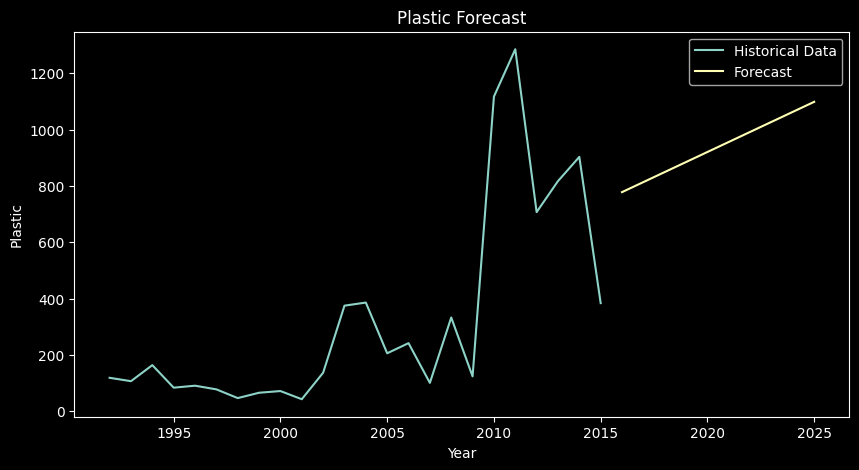

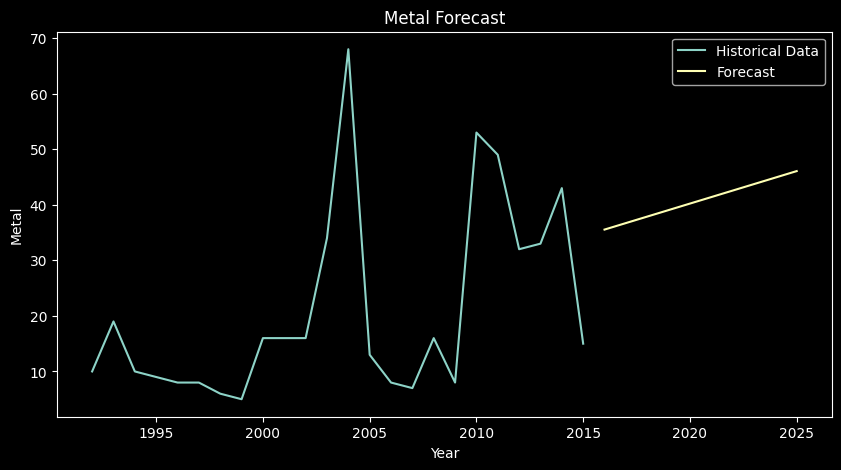

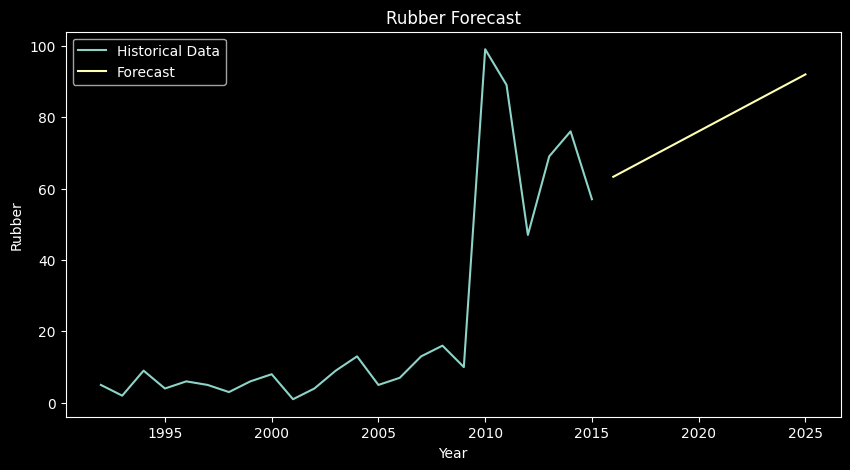

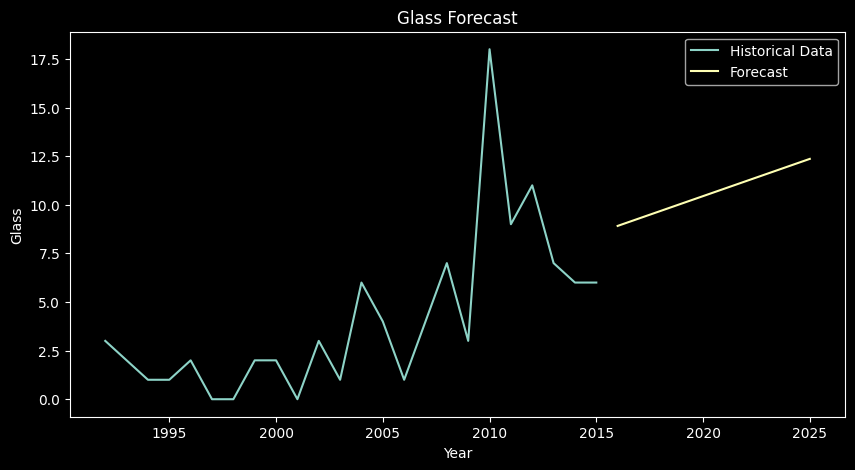

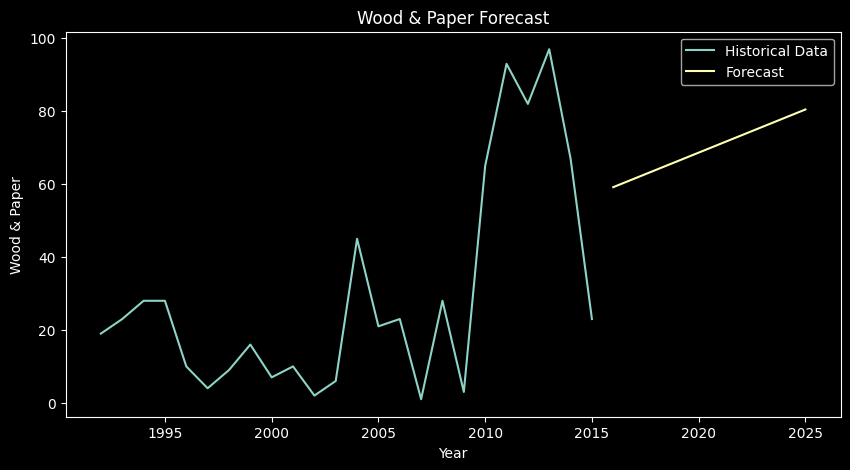

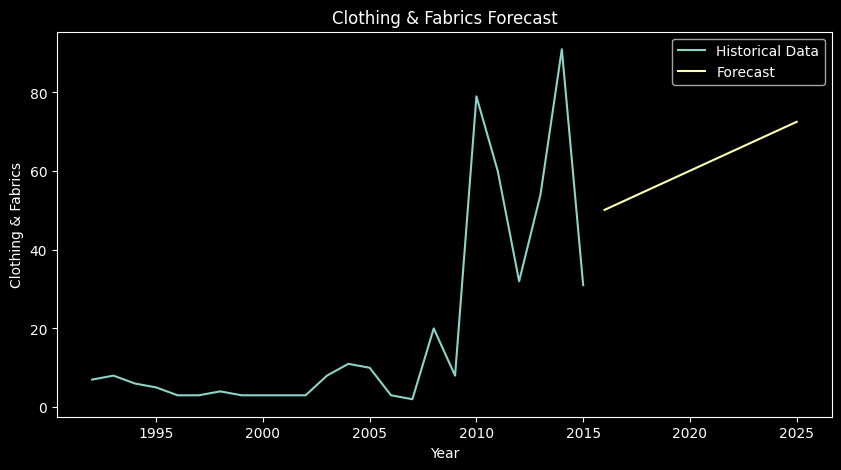

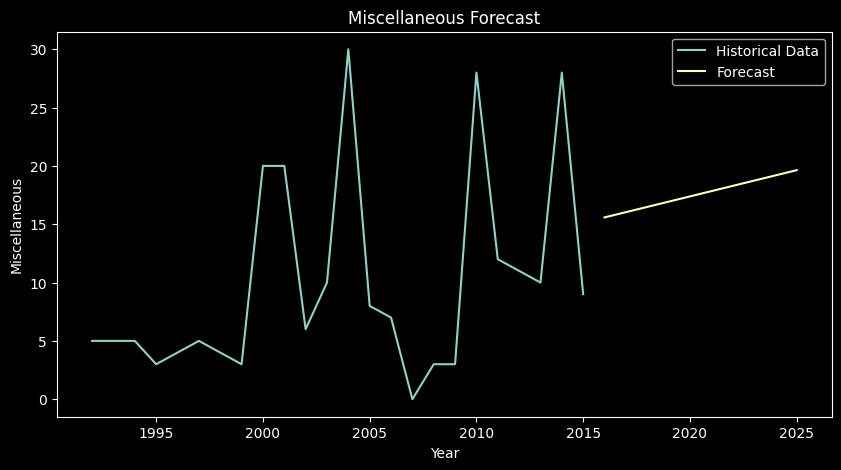

In [10]:
# Plot the predictions
plt.style.use('dark_background')

for category in df_yearly.columns:
    plt.figure(figsize=(10, 5))
    plt.plot(df_yearly.index, df_yearly[category], label='Historical Data')
    plt.plot(predict_years, df_predictions[category], label='Forecast')
    plt.xlabel('Year')
    plt.ylabel(category)
    plt.title(f'{category} Forecast')
    plt.legend()
    plt.show()

## AI Assisted Plot with Error Margin & Evaluation metrics

Category: Plastic
  Mean Squared Error (MSE): 64413.92
  R-squared (R²): 0.49


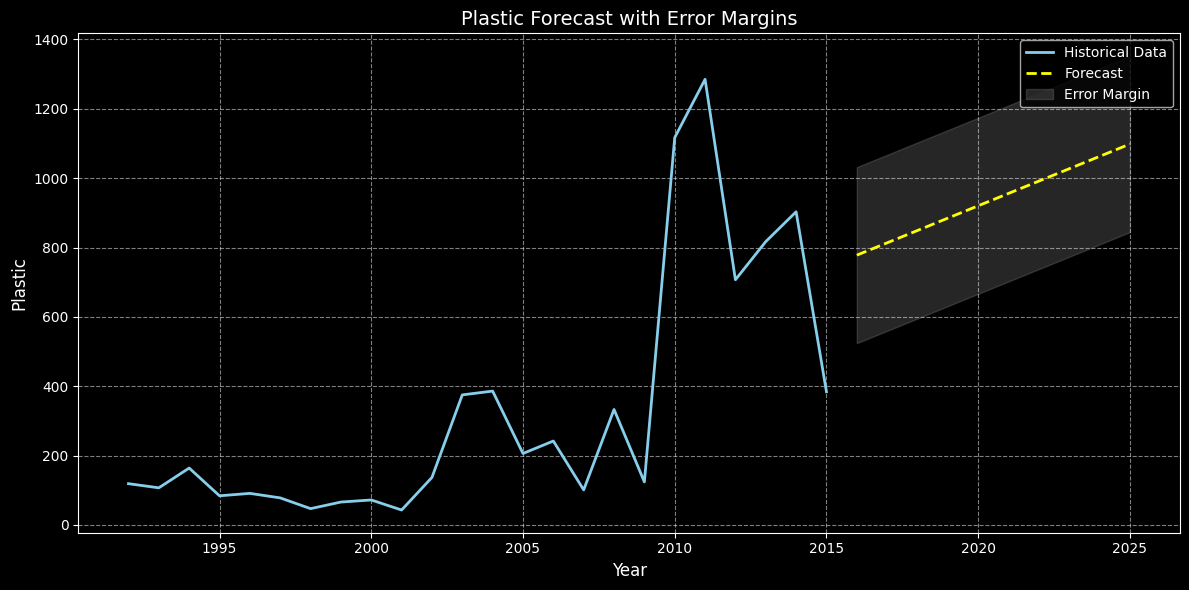

Category: Metal
  Mean Squared Error (MSE): 221.03
  R-squared (R²): 0.23


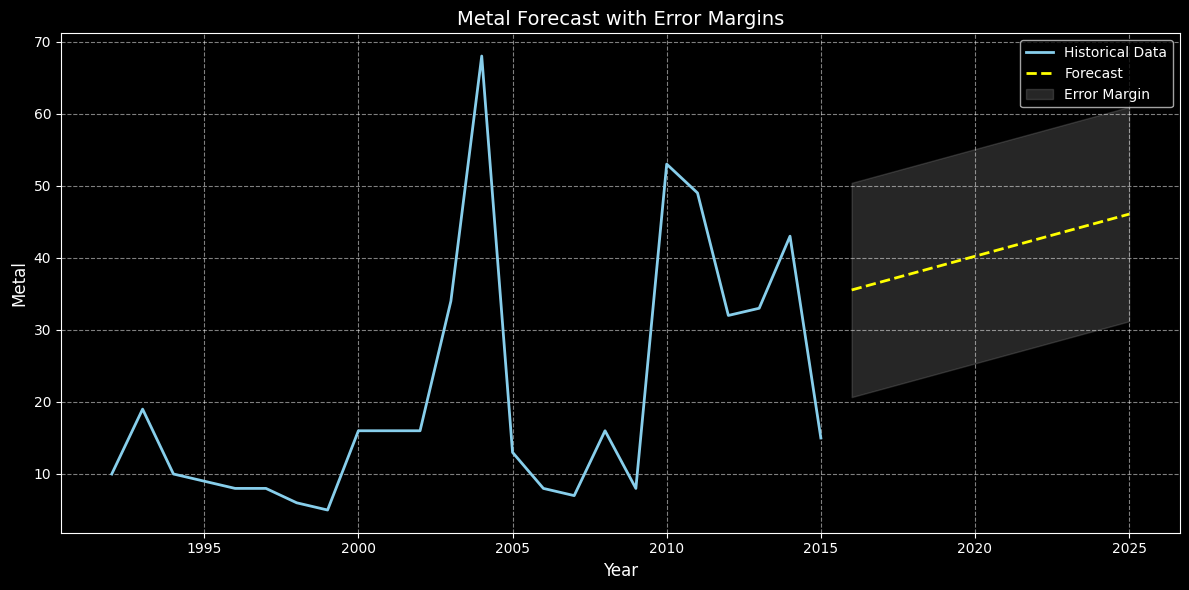

Category: Rubber
  Mean Squared Error (MSE): 416.72
  R-squared (R²): 0.54


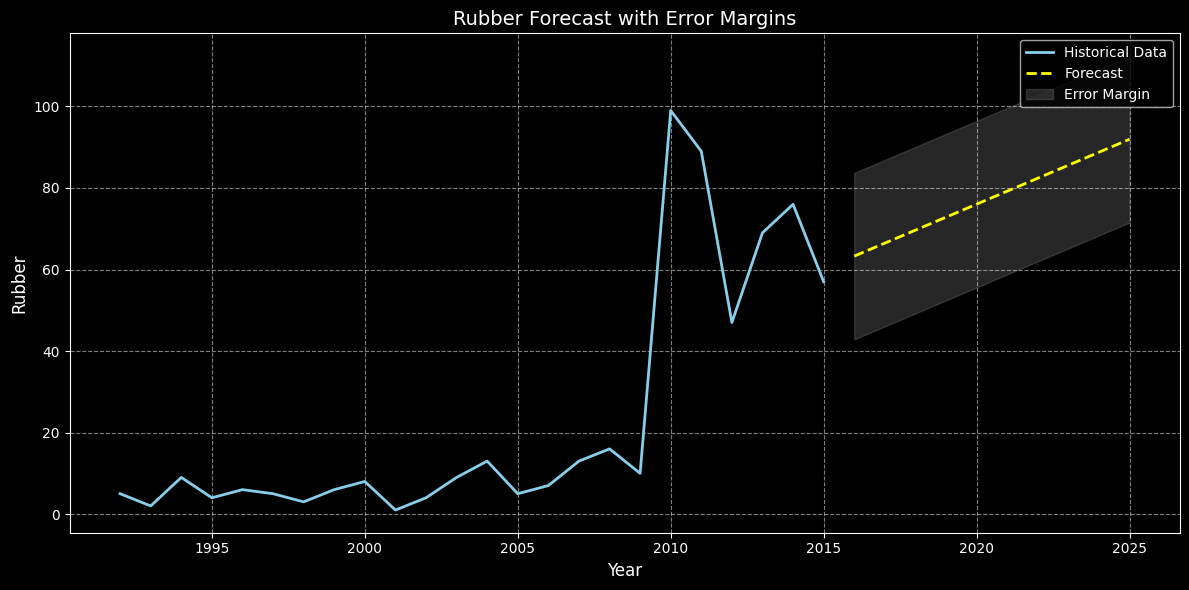

Category: Glass
  Mean Squared Error (MSE): 9.75
  R-squared (R²): 0.42


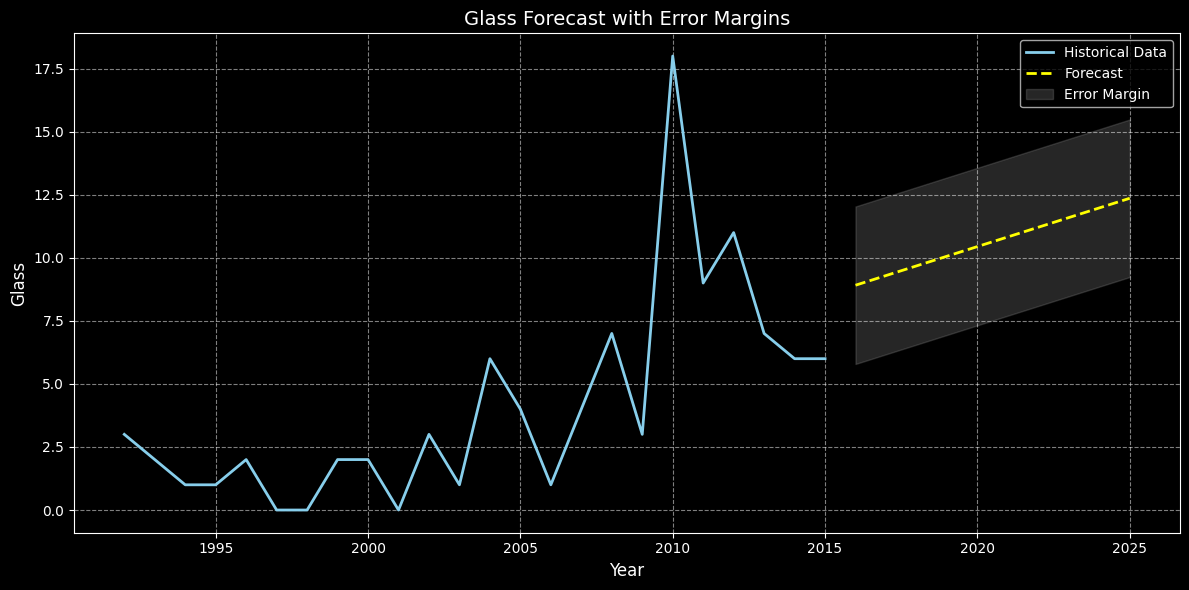

Category: Wood & Paper
  Mean Squared Error (MSE): 561.12
  R-squared (R²): 0.32


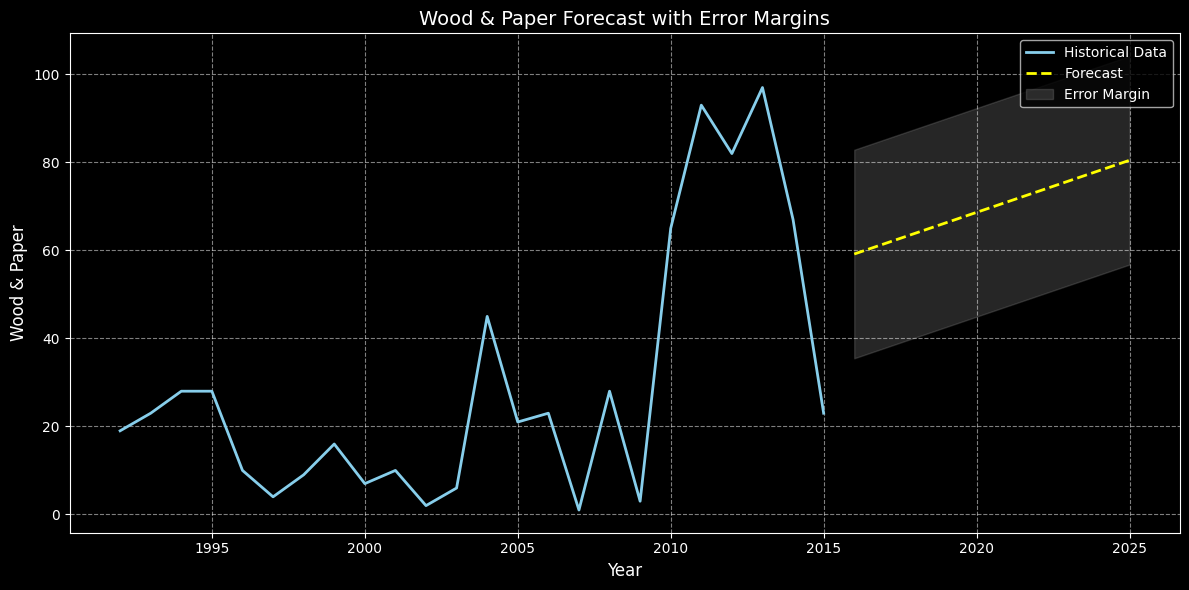

Category: Clothing & Fabrics
  Mean Squared Error (MSE): 341.95
  R-squared (R²): 0.46


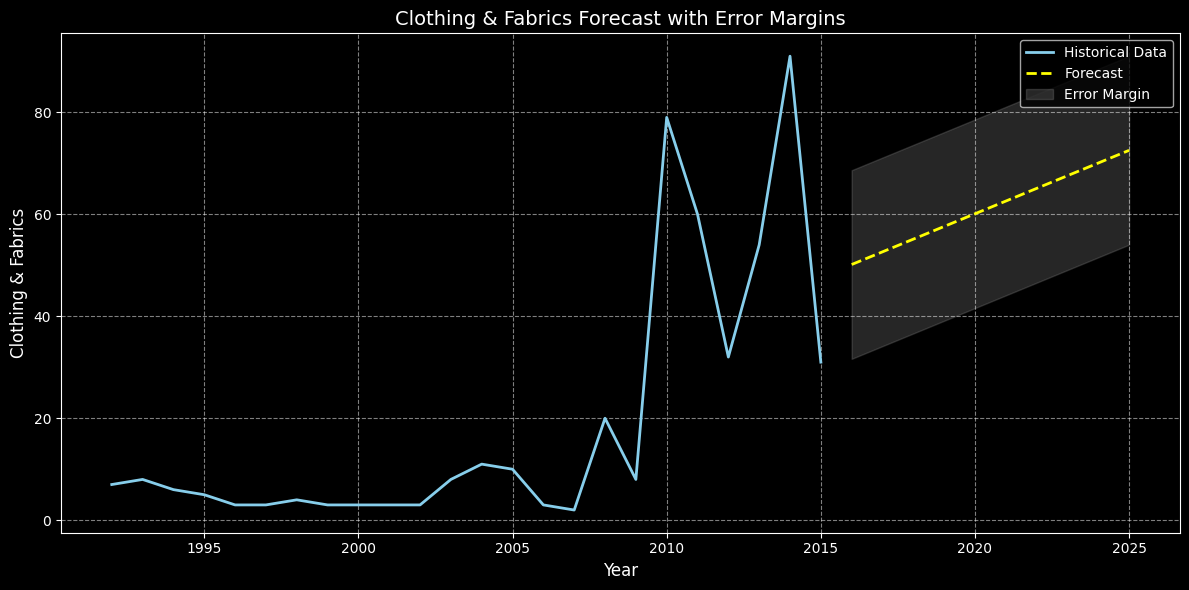

Category: Miscellaneous
  Mean Squared Error (MSE): 63.25
  R-squared (R²): 0.13


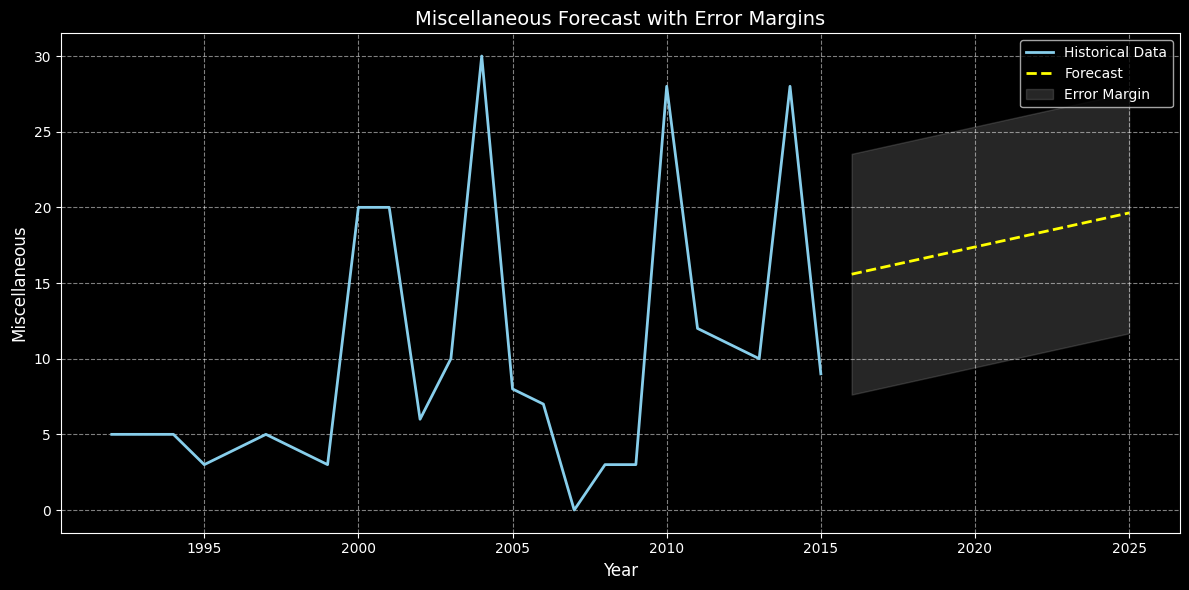

In [14]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Years to predict
predict_years = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

# Set the style
plt.style.use('dark_background')

for category in df_yearly.columns:
    model = LinearRegression()
    model.fit(df_yearly.index.values.reshape(-1, 1), df_yearly[category])
    predictions = model.predict([[year] for year in predict_years])

    # Calculate residuals for the historical data.
    historical_predictions = model.predict(df_yearly.index.values.reshape(-1,1))
    residuals = df_yearly[category] - historical_predictions
    std_dev = np.std(residuals)

    #Create upper and lower bounds.
    upper_bound = predictions + std_dev
    lower_bound = predictions - std_dev

    # Calculate MSE and R-squared
    mse = mean_squared_error(df_yearly[category], historical_predictions)
    r2 = r2_score(df_yearly[category], historical_predictions)

    # Print the evaluation metrics
    print(f"Category: {category}")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  R-squared (R²): {r2:.2f}")

    # Plot the forecasts with error margins
    plt.figure(figsize=(12, 6))
    plt.plot(df_yearly.index, df_yearly[category], label='Historical Data', color='skyblue', linewidth=2)
    plt.plot(predict_years, predictions, label='Forecast', color='yellow', linewidth=2, linestyle='--')
    plt.fill_between(predict_years, lower_bound, upper_bound, color='gray', alpha=0.3, label='Error Margin')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel(category, fontsize=12)
    plt.title(f'{category} Forecast with Error Margins', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

**Summary of Litter Forecast Analysis**

This notebook aimed to predict future trends in different types of marine litter using a linear regression model. Historical data from 1992 to 2015 was used to train the model and made predictions for the years 2016 to 2025. The analysis looked at seven litter categories: Plastic, Metal, Rubber, Glass, Wood & Paper, Clothing & Fabrics, and Miscellaneous.

--- 
**Evaluation of Model Performance**

The model’s performance was evaluated using two key metrics: Mean Squared Error (MSE) and R-squared (R²). The results showed that the model's accuracy varied across the different categories.

- MSE helps us understand how far off the model’s predictions are from the actual values. A lower MSE indicates better model performance, as it means the predictions are closer to the true values.

- R² measures the proportion of variance in the data explained by the model. An R² value closer to 1 indicates a better fit, while a lower value suggests that the model does not explain much of the data’s variability. 

The "Plastic" category had a high MSE (64413.92) and a moderate R² (0.49), indicating that the model wasn't very accurate for predicting plastic litter. In contrast, the "Glass" category had a low MSE (9.75) and a moderate R² (0.42), suggesting the model was more accurate for this category. The "Rubber" category had the highest R² value (0.54), meaning the model fit the rubber litter data the best. The other categories, including "Metal," "Wood & Paper," "Clothing & Fabrics," and "Miscellaneous," had moderate MSE and R² values, showing that the model's predictions were somewhat accurate but not perfect.

--- 
**Observed Trends and Limitations**

The forecasted data showed a consistent increase in all litter categories, suggesting that marine litter could rise over the coming years. However, it’s important to note the limitations of the linear regression model used in this study. Specifically, linear regression assumes that the relationship between the variables is linear, which can’t capture more complex, non-linear patterns in the data. For example, if the rate of increase in litter fluctuates or is influenced by multiple, interacting factors, the model may not reflect these dynamics accurately.

--- 
**Conclusion**

This study provides early insights into potential future trends in marine litter. Although the linear regression model showed varying levels of predictive accuracy, it’s clear that more advanced models and additional environmental factors are needed to improve future predictions.

**Future Recommendations**

- Look into using machine learning models that can better capture non-linear trends.